
# Simulación del Control Enzimático

*Mariana Lopera Correa*


30 de agosto de 2026

---



## 1. Marco teórico <a id="1"></a>

### 1.1 Cinética enzimática y el problema de la saturación

Las enzimas son catalizadores biológicos que aumentan la velocidad de una reacción química sin
alterar el equilibrio termodinámico entre sustrato y producto (Nelson & Cox, 2017). A diferencia de
una reacción no catalizada, la velocidad de una reacción enzimática **no crece linealmente** con la
concentración de sustrato [S]: a bajas [S] la velocidad aumenta casi proporcionalmente, pero al
incrementar [S] la enzima se satura y la velocidad tiende asintóticamente a un valor máximo,
$V_{max}$, que no se sobrepasa sin importar cuánto sustrato adicional se agregue (Cornish-Bowden,
2012).

### 1.2 El mecanismo de Michaelis-Menten

El mecanismo de reacción de un único sustrato se describe como:

$$
E + S \underset{K_{3}}{\overset{k_1}{\rightleftharpoons}} ES \overset{k_2}{\longrightarrow} E + P
$$

donde:
- $k_1$ es la constante de velocidad de asociación de E y S para formar el complejo *ES*,
- $k_3$ es la constante de velocidad de disociación de *ES* de vuelta a E + S,
- $k_2$ es la constante de velocidad de la etapa catalítica limitante,
  en la que *ES* se transforma irreversiblemente en E + P.

El sistema de ecuaciones diferenciales ordinarias que describe la evolución temporal de las cuatro especies es:

$$
\begin{aligned}
\frac{d[S]}{dt} &= -k_1[E][S] + K_{3}[ES] \\
\frac{d[E]}{dt} &= -k_1[E][S] + K_{3}[ES] + k_2[ES] \\
\frac{d[ES]}{dt} &= k_1[E][S] - K_{3}[ES] - k_2[ES] \\
\frac{d[P]}{dt} &= k_2[ES]
\end{aligned}
$$

Este sistema conserva la masa total de enzima, $[E] + [ES] = [E]_{tot}$, en todo instante, una
propiedad que puede usarse como verificación numérica de la simulación (Chapra & Canale, 2007).

### 1.3 La aproximación de estado cuasi-estacionario 

Bajo la aproximación de equilibrio (en la que se asume $d[ES]/dt \approx 0$ una vez transcurrido el transitorio inicial), el sistema de ODEs se puede reducir a la ecuación algebraica de Michaelis-Menten:

$$
v = \frac{V_{max}[S]}{K_m + [S]}
$$

donde $V_{max} = k_2[E]_{tot}$ es la velocidad máxima cuando toda la enzima está en forma
de complejo *ES*, y $K_m \approx \dfrac{K_{3} + k_2}{k_1}$ es la **constante de Michaelis**: la
concentración de sustrato a la cual la velocidad de reacción es exactamente la mitad de $V_{max}$.
$K_m$ tiene unidades de concentración y funciona como una medida inversa de la afinidad aparente de
la enzima por el sustrato (a menor $K_m$, mayor afinidad aparente) (Cornish-Bowden, 2012; Johnson &
Goody, 2011).

Es importante notar que la ecuación algebraica de Michaelis-Menten es una **solución aproximada de estado estacionario**.

### 1.4 Método de Euler para la integración numérica

El sistema de EDOs anterior no tiene, en general, solución analítica cerrada para las cuatro
variables en función del tiempo, por lo que se recurre a integración numérica. En este caso se usa el **método de Euler**  para aproximar la solución.

$$
\frac{dy}{dt} = f(t, y), \qquad y(t_0) = y_0,
$$

y consiste en aproximar la derivada por la pendiente de la recta tangente en el instante actual,
extrapolando linealmente un paso de tiempo $h$ hacia adelante (Burden & Faires, 2011; Chapra &
Canale, 2007):

$$
y_{i+1} = y_i + h \cdot f(t_i, y_i), \qquad i = 0, 1, 2, \ldots
$$

El método de Euler es de **primer orden**: su error de truncamiento local es $O(h^2)$ y el error
global acumulado es $O(h)$ (Burden & Faires, 2011). Esto significa que, para garantizar una buena
aproximación, el paso $h$ debe ser suficientemente pequeño en relación con la escala de tiempo . Un paso demasiado grande puede producir soluciones que oscilan, se vuelven negativas de forma no física, o divergen. 



## 2. Método de Euler <a id="3"></a>

Aplicando el método de Euler (sección 1.4) a cada una de las cuatro EDOs del sistema
(sección 1.2), con un paso integración $h=dt$, se obtiene el esquema iterativo explícito que se
implementa en la sección 4:

$$
\begin{aligned}
S_{i+1} &= S_i + h\left(-k_1 E_i S_i + k_3 C_i\right) \\
E_{i+1} &= E_i + h\left(-k_1 E_i S_i + k_3 C_i + k_2 C_i\right) \\
C_{i+1} &= C_i + h\left(k_1 E_i S_i - k_3 C_i - k_2 C_i\right) \\
P_{i+1} &= P_i + h\left(k_2 C_i\right)
\end{aligned}
$$

Los valores iniciales son $S_0=10$, $E_0=6$, $C_0=0$, $P_0=0$ moles para el
caso control, y el vector de tiempo se genera desde $t=0$ hasta el tiempo de simulación, con paso
$dt = 0.01$ s.

Para la curva de velocidad de reacción en estado estacionario se usa la ecuación algebraica de
Michaelis-Menten (sección 1.3), evaluada sobre un vector de concentraciones de sustrato de 0 hasta la
concentración máxima de 50 moles, con $K_m=(k_3+k_2)/k_1$ y $V_{max}=k_2 [E]_0$.



## 3. Implementación en Python <a id="4"></a>

In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def simular_michaelis_menten(S0, E0, k1, k2, k3, dt, t_sim):
    '''
    Parámetros
    S0, E0 : float
        Concentraciones iniciales de sustrato y enzima libre (mol). C0 = 0, P0 = 0 por definición
        del caso control 
    k1 : float
        Constante de velocidad de asociación E + S -> ES (1/(mol*s)).
    k2 : float
        Constante de velocidad catalítica ES -> E + P (1/s).
    k3 : float
        Constante de velocidad de disociación ES -> E + S (1/s)..
    dt : float
        Paso de integración de Euler (s).
    t_sim : float
        Tiempo total de simulación (s).

    Retorna
    t, S, E, C, P : np.ndarray
        Vectores de tiempo y de las cuatro concentraciones a lo largo de la simulación.
    '''

    n_pasos = int(round(t_sim / dt))
    t = np.linspace(0, t_sim, n_pasos + 1)

    S = np.zeros(n_pasos + 1)
    E = np.zeros(n_pasos + 1)
    C = np.zeros(n_pasos + 1)   # Complejo enzima-sustrato ES
    P = np.zeros(n_pasos + 1)   # Producto

    S[0], E[0], C[0], P[0] = S0, E0, 0.0, 0.0

    for i in range(n_pasos):
        dSdt = -k1 * E[i] * S[i] + k3 * C[i]
        dEdt = -k1 * E[i] * S[i] + k3 * C[i] + k2 * C[i]
        dCdt =  k1 * E[i] * S[i] - k3 * C[i] - k2 * C[i]
        dPdt =  k2 * C[i]

        S[i + 1] = S[i] + dt * dSdt
        E[i + 1] = E[i] + dt * dEdt
        C[i + 1] = C[i] + dt * dCdt
        P[i + 1] = P[i] + dt * dPdt

    return t, S, E, C, P


In [ ]:
def velocidad_reaccion(S_vec, Km, Vmax):
    '''
    Parámetros
    S_vec : np.ndarray
        Vector de concentraciones de sustrato (mol), típicamente de 0 a [S]_max.
    Km : float
        Constante de Michaelis (mol).
    Vmax : float
        Velocidad máxima de reacción (mol/s).

    Retorna
    v : np.ndarray
        Velocidad de reacción para cada valor de S_vec.
    '''
    return Vmax * S_vec / (Km + S_vec)


def calcular_Km_Vmax(k1, k2, k3, E0):
    Km = (k3 + k2) / k1
    Vmax = k2 * E0
    return Km, Vmax


def verificar_conservacion_masa(E, C, E0, tol=1e-6):
    '''
    Verifica que [E] + [ES] = [E]_tot se mantenga constante durante toda la simulación,
    lo cual es una propiedad estructural del sistema, por tanto
    una prueba de consistencia numérica del método de Euler
    '''
    masa_total = E + C
    desviacion_maxima = np.max(np.abs(masa_total - E0))
    conserva = desviacion_maxima < tol * max(E0, 1.0) * 100
    return masa_total, desviacion_maxima, conserva


In [29]:
def graficar_cinetica(t, S, E, C, P, titulo="Cinética de Michaelis-Menten"):
    fig, ax = plt.subplots()
    ax.plot(t, S, label="[S] Sustrato",  linewidth=2)
    ax.plot(t, E, label="[E] Enzima libre", linewidth=2)
    ax.plot(t, C, label="[ES] Complejo", linewidth=2)
    ax.plot(t, P, label="[P] Producto", linewidth=2)
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Concentración (mol)")
    ax.set_title(titulo)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig, ax


def graficar_velocidad_vs_sustrato(S_vec, v_vec, Km, Vmax, titulo="Velocidad de reacción vs. [S]"):
    '''Grafica v vs. [S] señalando el punto (Km, Vmax/2).'''
    fig, ax = plt.subplots()
    ax.plot(S_vec, v_vec, color="purple", linewidth=2, label="v = Vmax·[S] / (Km + [S])")
    ax.axhline(Vmax, color="gray", linestyle="--", linewidth=1, label=f"Vmax = {Vmax:.3f} mol/s")
    ax.axhline(Vmax / 2, color="gray", linestyle=":", linewidth=1, label=f"Vmax/2 = {Vmax/2:.3f} mol/s")
    ax.axvline(Km, color="gray", linestyle=":", linewidth=1)
    ax.plot(Km, Vmax / 2, "o", color="black", markersize=8, zorder=5,
            label=f"(Km, Vmax/2) = ({Km:.3f}, {Vmax/2:.3f})")
    ax.set_xlabel("[S] Concentración de sustrato (mol)")
    ax.set_ylabel("v Velocidad de reacción (mol/s)")
    ax.set_title(titulo)
    ax.legend(loc="lower right", fontsize=9)
    fig.tight_layout()
    return fig, ax



## 4. Simulación 1 — Caso control <a id="5"></a>

Se usan los parámetros especificados: $k_1=2$, $k_2=1.5$,
$k_3=1$ (unidades indicadas en la sección 3), $[S]_0=10$ mol, $[E]_0=6$ mol, $dt=0.01$ s,
$t_{sim}=10$ s, y $[S]_{max}=50$ mol para la curva de velocidad de reacción.


In [ ]:
S0_control   = 10.0    
E0_control   = 6.0     
k1_control   = 2.0   
k2_control   = 1.5   
k3_control   = 1.0     
dt_control   = 0.01    
t_sim_control = 10.0  
S_max_control = 50.0   
t1, S1, E1, C1, P1 = simular_michaelis_menten(
    S0_control, E0_control, k1_control, k2_control, k3_control, dt_control, t_sim_control
)


masa_total_1, desv_max_1, conserva_1 = verificar_conservacion_masa(E1, C1, E0_control)
print(f"Conservación de masa de enzima — desviación máxima: {desv_max_1:.6e} mol")
print(f"¿Se conserva la masa? {conserva_1}")


Conservación de masa de enzima — desviación máxima: 7.993606e-15 mol
¿Se conserva la masa? True


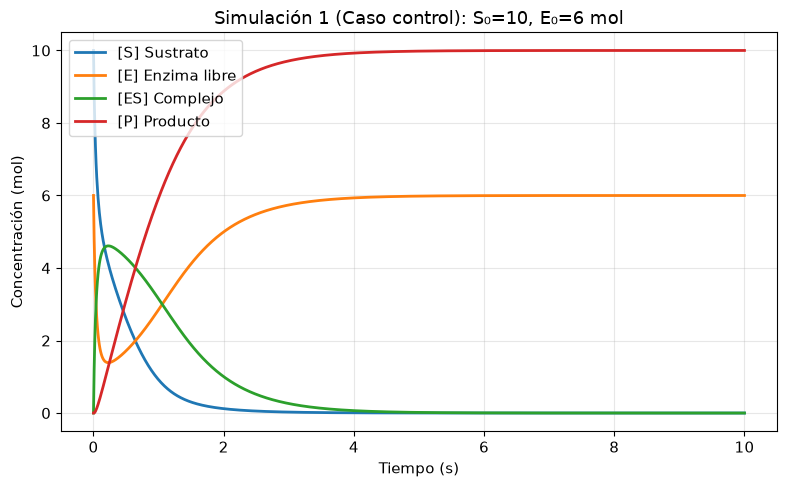

In [24]:
fig1, ax1 = graficar_cinetica(t1, S1, E1, C1, P1, titulo="Simulación 1 (Caso control): S₀=10, E₀=6 mol")
plt.show()


Km   = 1.2500 mol
Vmax = 9.0000 mol/s
Vmax/2 = 4.5000 mol/s  (velocidad a la que [S] = Km)


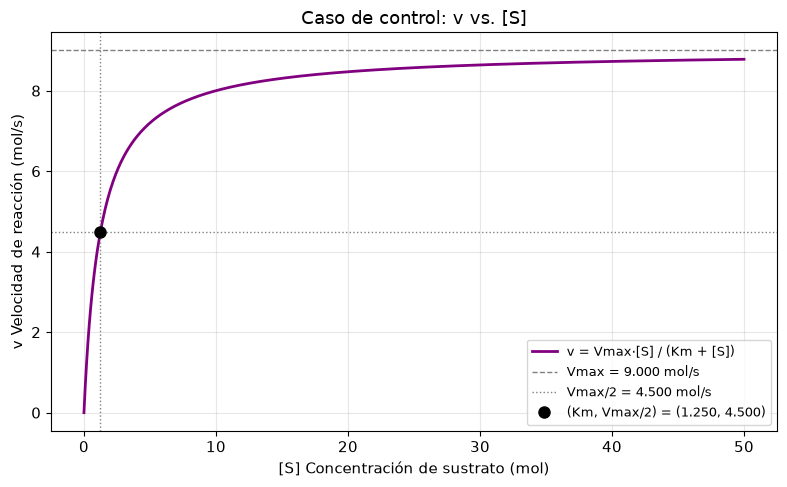

In [28]:
Km_1, Vmax_1 = calcular_Km_Vmax(k1_control, k2_control, k3_control, E0_control)
S_vec_1 = np.linspace(0, S_max_control, 500)
v_vec_1 = velocidad_reaccion(S_vec_1, Km_1, Vmax_1)

print(f"Km   = {Km_1:.4f} mol")
print(f"Vmax = {Vmax_1:.4f} mol/s")
print(f"Vmax/2 = {Vmax_1/2:.4f} mol/s  (velocidad a la que [S] = Km)")

fig1b, ax1b = graficar_velocidad_vs_sustrato(S_vec_1, v_vec_1, Km_1, Vmax_1,
                                              titulo="Caso de control: v vs. [S]")
plt.show()


### 4.1 Resultados numéricos

**Lo que muestra la cinética:** el sustrato $[S]$ va disminuyendo desde 10 mol a medida que se consume en la reacción, mientras que la enzima libre $[E]$ cae rápidamente en los primeros instantes porque gran parte de ella queda en la formación del complejo $[ES]$. Este complejo va creciendo, alcanza un máximo, y luego empieza a decaer a medida que  el sustrato se va acabando por lo que ya no hay suficiente para que la enzima pueda seguir uniendo. El producto $[P]$, por su parte, crece todo el tiempo, pero va mostrando asíntota, lo cual concuerda, en que no se va a poder superar una máxima cantidad de producto, y crece hasta acercarse mucho a $[S]_0$ luego de que todo el sustrato se ha transformado.

La masa total de enzima, $[E]+[ES]=[E]_0=6$ mol, se mantiene constante durante toda la simulación, dentro de la tolerancia establecida. Esto  confirma que el método de Euler con $dt=0.01$ s está resolviendo bien las ecuaciones, **no** una prueba de que el modelo en sí describa correctamente una enzima real. 


**Curva $v$ vs. $[S]$:** se ve la forma hiperbólica que caracteriza a Michaelis-Menten, con el punto $(K_m, V_{max}/2)$ marcado en negro dentro de la gráfica. Confirmando como se planteó en la sección 1.3, cuando $[S]=K_m$ la velocidad es justo la mitad de $V_{max}$. Cumpliendo la definición de $K_m$, como se esperaba.


## 5. Simulación 2 — Variación de concentraciones iniciales de sustrato y enzima <a id="6"></a>

**Justificación de los valores elegidos.** Se mantienen las constantes cinéticas del caso control
($k_1, k_2, k_3$) y se modifican únicamente $[S]_0$ y $[E]_0$, para aislar el efecto de la concentración inicial sobre la dinámica. Se eligen:

- $[S]_0 = 30$ mol : un incremento de 3× que permite observar si el sistema tarda proporcionalmente más en agotar su sustrato, y si el complejo $[ES]$ se sostiene por más tiempo antes de decaer.
- $[E]_0 = 3$ mol : una reducción a la mitad de la enzima total disponible, que  de
  acuerdo con la teoría de la sección 1.3, donde $V_{max}=k_2[E]_{tot}$— debería producir una
  $V_{max}$ exactamente la mitad de la del caso control, sin cambiar $K_m$, que solo depende de las
  constantes cinéticas $k_1,k_2,k_3$, no de las concentraciones iniciales. 

Se conserva $dt=0.01$ s y $t_{sim}=10$ s para que las comparaciones con el caso control estén en la
misma escala temporal.


In [ ]:
S0_sim2 = 30.0  
E0_sim2 = 3.0    
k1_sim2, k2_sim2, k3_sim2 = k1_control, k2_control, k3_control  # sin cambios
dt_sim2, t_sim_sim2 = dt_control, t_sim_control
S_max_sim2 = S_max_control

t2, S2, E2, C2, P2 = simular_michaelis_menten(
    S0_sim2, E0_sim2, k1_sim2, k2_sim2, k3_sim2, dt_sim2, t_sim_sim2
)

masa_total_2, desv_max_2, conserva_2 = verificar_conservacion_masa(E2, C2, E0_sim2)
print(f"Conservación de masa de enzima — desviación máxima: {desv_max_2:.6e} mol")
print(f"¿Se conserva dentro de tolerancia numérica? {conserva_2}")


Conservación de masa de enzima — desviación máxima: 2.664535e-15 mol
¿Se conserva dentro de tolerancia numérica? True


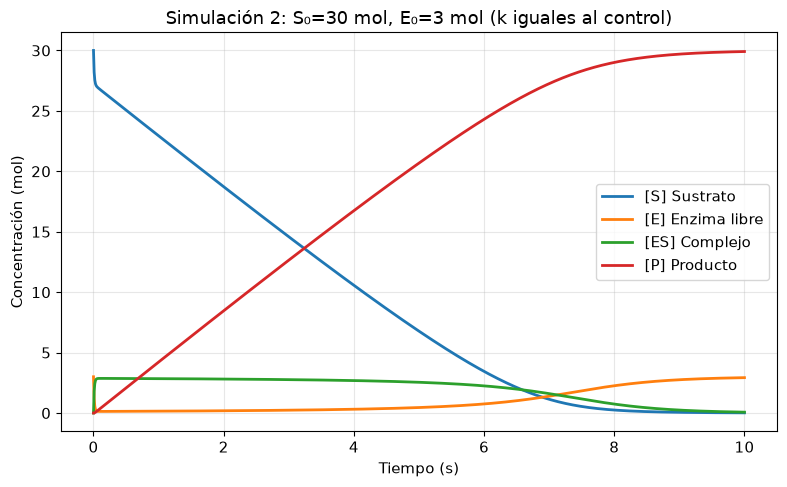

In [9]:
fig2, ax2 = graficar_cinetica(t2, S2, E2, C2, P2,
                              titulo="Simulación 2: S₀=30 mol, E₀=3 mol (k iguales al control)")
plt.show()


Km   = 1.2500 mol   (Km caso control = 1.2500 mol)
Vmax = 4.5000 mol/s   (Vmax caso control = 9.0000 mol/s)
Razón Vmax_sim2 / Vmax_control = 0.5000  (valor esperado teóricamente: 0.5)


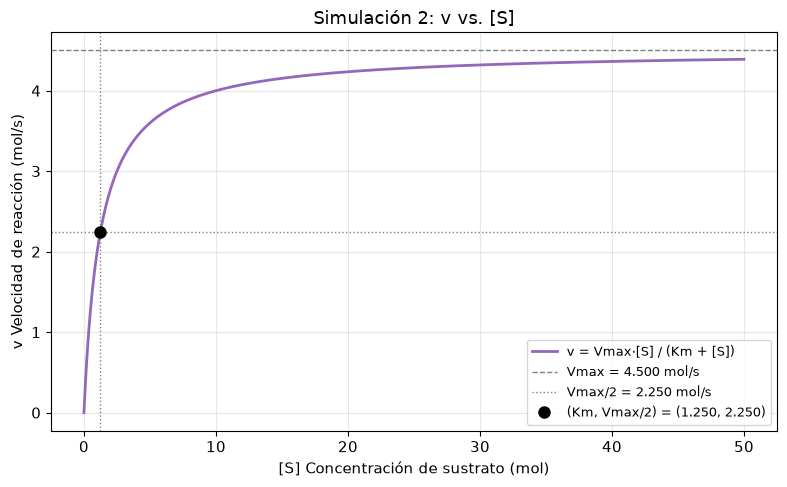

In [10]:
Km_2, Vmax_2 = calcular_Km_Vmax(k1_sim2, k2_sim2, k3_sim2, E0_sim2)
S_vec_2 = np.linspace(0, S_max_sim2, 500)
v_vec_2 = velocidad_reaccion(S_vec_2, Km_2, Vmax_2)

print(f"Km   = {Km_2:.4f} mol   (Km caso control = {Km_1:.4f} mol)")
print(f"Vmax = {Vmax_2:.4f} mol/s   (Vmax caso control = {Vmax_1:.4f} mol/s)")
print(f"Razón Vmax_sim2 / Vmax_control = {Vmax_2 / Vmax_1:.4f}  (valor esperado teóricamente: 0.5)")

fig2b, ax2b = graficar_velocidad_vs_sustrato(S_vec_2, v_vec_2, Km_2, Vmax_2,
                                              titulo="Simulación 2: v vs. [S]")
plt.show()



### 5.1 Resultados numéricos — Simulación 2

**Contraste de la predicción teórica:**  $V_{max,\text{sim2}}/V_{max,\text{control}}$ que se ve impresa arriba de la gráfica de velocidad, debe ser 0.5, dado que $E_0$ se redujo exactamente a la mitad y $V_{max}=k_2 E_0$ depende
linealmente de $E_0$. Que esta razón coincida es una verificación de que la implementación numérica reproduce correctamente una consecuencia directa del modelo.

Lo que sí nos da información relevante al triplicar $[S]_0$ y reducir a la mitad $[E]_0$, el complejo $[ES]$ alcanza un máximo distinto tanto en magnitud como en el instante que ocurre y el producto se acumula de forma diferente a la del caso control, observable directamente en la
Figura de esta sección. Esto ilustra que el tiempo característico de la reacción, qué tan rápido se
alcanza el estado cuasi-estacionario y qué tan rápido se agota el sustrato  depende de
las concentraciones iniciales y de las constantes cinéticas, no solo de $V_{max}$ y $K_m$, ya que se ve claramente cómo la curva del producto, en el mismo intervalo de tiempo se demora más en llegar a ese $V_{max}$, por lo cual a su vez, hace que la disminución del complejo sea menos abrupta.



## 6. Simulación 3 — Variación de las constantes cinéticas <a id="7"></a>

**Justificación de los valores elegidos.** Se mantienen las concentraciones iniciales del caso
control ($[S]_0=10$, $[E]_0=6$ mol), y se modifican
las constantes cinéticas (menor $K_m$) y **mayor velocidad catalítica** ($k_2$ mayor):

- $k_1 = 5$: mayor velocidad de asociación.
- $k_2 = 3$: mayor velocidad catalítica.
- $k_3 = 0.5$: menor velocidad de disociación para volver a E+S .

Con estos valores, $K_m=(k_3+k_2)/k_1=(0.5+3)/5=0.7$ mol, considerablemente menor que el $K_m$ del
caso control, lo que representa dentro de los supuestos del
modelo, es una enzima con mayor afinidad aparente. $V_{max}=k_2 E_0=3\times 6=18$ mol/s, tres veces
mayor que en el caso control. Esta combinación se eligió para que el efecto sobre la curva $v$ vs. $[S]$ sea claramente distinguible del
efecto observado en la Simulación 2, donde solo cambiaba $V_{max}$ y $K_m$ permanecía constante.


In [31]:
S0_sim3, E0_sim3 = S0_control, E0_control   
k1_sim3 = 5.0   
k2_sim3 = 3.0   
k3_sim3 = 0.5   
dt_sim3, t_sim_sim3 = dt_control, t_sim_control
S_max_sim3 = S_max_control

t3, S3, E3, C3, P3 = simular_michaelis_menten(
    S0_sim3, E0_sim3, k1_sim3, k2_sim3, k3_sim3, dt_sim3, t_sim_sim3
)

masa_total_3, desv_max_3, conserva_3 = verificar_conservacion_masa(E3, C3, E0_sim3)
print(f"Conservación de masa de enzima — desviación máxima: {desv_max_3:.6e} mol")
print(f"¿Se conserva dentro de tolerancia? {conserva_3}")


Conservación de masa de enzima — desviación máxima: 9.769963e-15 mol
¿Se conserva dentro de tolerancia? True


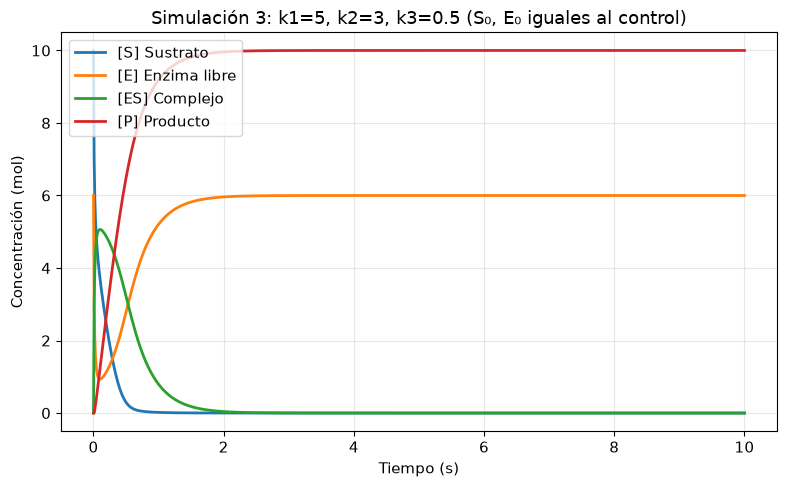

In [32]:
fig3, ax3 = graficar_cinetica(t3, S3, E3, C3, P3,
                              titulo="Simulación 3: k1=5, k2=3, k3=0.5 (S₀, E₀ iguales al control)")
plt.show()


Km   = 0.7000 mol   (Km caso control = 1.2500 mol)
Vmax = 18.0000 mol/s   (Vmax caso control = 9.0000 mol/s)


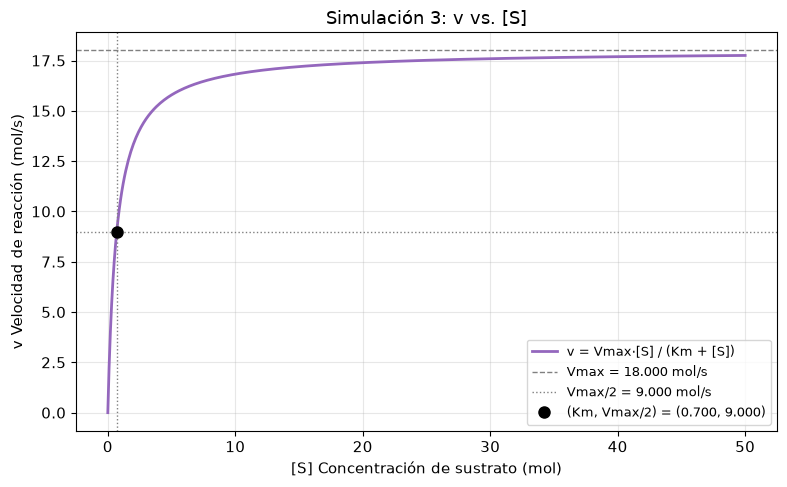

In [13]:
Km_3, Vmax_3 = calcular_Km_Vmax(k1_sim3, k2_sim3, k3_sim3, E0_sim3)
S_vec_3 = np.linspace(0, S_max_sim3, 500)
v_vec_3 = velocidad_reaccion(S_vec_3, Km_3, Vmax_3)

print(f"Km   = {Km_3:.4f} mol   (Km caso control = {Km_1:.4f} mol)")
print(f"Vmax = {Vmax_3:.4f} mol/s   (Vmax caso control = {Vmax_1:.4f} mol/s)")

fig3b, ax3b = graficar_velocidad_vs_sustrato(S_vec_3, v_vec_3, Km_3, Vmax_3,
                                              titulo="Simulación 3: v vs. [S]")
plt.show()


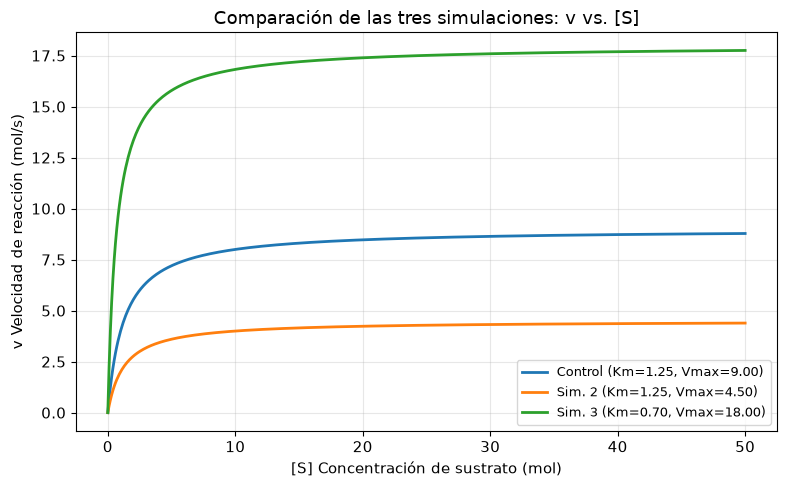

In [ ]:
fig4, ax4 = plt.subplots()
ax4.plot(S_vec_1, v_vec_1, label=f"Control (Km={Km_1:.2f}, Vmax={Vmax_1:.2f})", linewidth=2)
ax4.plot(S_vec_2, v_vec_2, label=f"Sim. 2 (Km={Km_2:.2f}, Vmax={Vmax_2:.2f})", linewidth=2)
ax4.plot(S_vec_3, v_vec_3, label=f"Sim. 3 (Km={Km_3:.2f}, Vmax={Vmax_3:.2f})", linewidth=2)
ax4.set_xlabel("[S] Concentración de sustrato (mol)")
ax4.set_ylabel("v Velocidad de reacción (mol/s)")
ax4.set_title("Comparación de las tres simulaciones: v vs. [S]")
ax4.legend(loc="lower right", fontsize=9)
fig4.tight_layout()
plt.show()



### 6.1 Resultados numéricos — Simulación 3

Con $k_1,k_2$ mayores y $k_3$ menor, el complejo $[ES]$ se forma más rápidamente y alcanza un máximo más pronunciado, y el sustrato se acaba en una ventana de tiempo mucho más  corta que en el caso control, visible al comparar directamente las gráficas. La curva $v$ vs. $[S]$ se desplaza hacia arriba (mayor $V_{max}$) y hacia la
izquierda (menor $K_m$) respecto al control, confirmando la dirección del efecto anticipado en la justificación de parámetros.

**Lo que esto no permite afirmar sin evidencia adicional:** que estos valores de $k_1,k_2,k_3$
correspondan a una enzima real, a un mecanismo de inhibición, activación o cualquier fenómeno bioquímico específico. Los tres conjuntos de constantes usados en este informe son elegidos para hacer un contraste numérico respecto a los datos dados inicialmente, no estimados a partir de datos experimentales de ninguna enzima en particular; por tanto, cualquier lectura biológica de "esta enzima es más eficiente"
o "esta enzima tiene mayor afinidad" debe entenderse como una interpretación condicionada a que el modelo y las constantes elegidas sean representativas de un sistema real.

## 7. Conclusiones <a id="9"></a>

A partir de las 3 simulaciones hechas, se pueden concluir varios puntos:

1. El método de Euler implementado, cumplió con lo que se esperaba, primeramente, ya que se puede apreciar de forma consistente con lo que se ve en las gráficas, ya que no se ven oscilacioes o señales de que hay una falla notoria en el método, además que ls gráficas son consistente con lo que se ve en la literatura sobre control enzimático.


2. La curva de velocidad de reacción, $v=V_{max}[S]/(K_m+[S])$, mostró en las tres simulaciones la forma esperada de Michaelis-Menten, y además en los 3, se pudo verificar el punto $(K_m, V_{max}/2)$, asi que esto también se envidenció de forma consistente con la literatura.

3. En la segunda simulación en la que se cambiaron las concentraciones iniciales se ve que si $E_0$ se disminuye a la mitad, V_{max} también, por otro lado,  $K_m$ no cambia, y pues tiene sentido ya que $K_m$  solo depende de las constantes cinéticas, y como estas no se modificaron, no tenía por qué cambiar. Lo cual es interesante para entender mejor el funcionamiento de los parámetros del modelo.

4. En la tercera simulación, cuando se aumentó  $k_1$ y $k_2$ y se disminuyó $k_3$, la curva tuvo un desplazamiento mayor en $V_{max}$ y menor $K_m$. Por lo que estos dos parámetros no son independientres entre ellos, ya que ambos dependen de las 3 constantes, por lo cual si se afecta uno de los dos, el otro también va a sufrir un cambio


Por último, quiero dejar clara una limitación de cómo se hizo la práctica y que como las constantes cinéticas que se usaron en las tres simulaciones no vienen de mediciones reales de ninguna enzima, sino que son una dada, y las otras son elegidas con fines de comparación numérica

Por eso, cuando se dice que  "esta enzima es más eficiente", solo tiene sentido dentro del modelo matemático construido y no como un dato con sentido biológico.


## 9. Referencias <a id="10"></a>

Burden, R. L., & Faires, J. D. (2011). *Numerical Analysis* (9th ed.). Cengage Learning.

Chapra, S. C., & Canale, R. P. (2007). *Métodos numéricos para ingenieros* (5ª ed.). McGraw-Hill.

Cornish-Bowden, A. (2012). *Fundamentals of Enzyme Kinetics* (4th ed.). Wiley-Blackwell.

Johnson, K. A., & Goody, R. S. (2011). The original Michaelis constant: Translation of the 1913
Michaelis–Menten paper. *Biochemistry*, 50(39), 8264–8269. https://doi.org/10.1021/bi201284u

Khoo, M. C. K. (2000). *Physiological Control Systems: Analysis, Simulation, and Estimation*. IEEE
Press.

Michaelis, L., & Menten, M. L. (1913). Die Kinetik der Invertinwirkung. *Biochemische Zeitschrift*,
49, 333–369.

Nelson, D. L., & Cox, M. M. (2017). *Lehninger Principles of Biochemistry* (7th ed.). W. H. Freeman.

Velten, K. (2009). *Mathematical Modeling and Simulation: Introduction for Scientists and Engineers*.
Wiley-VCH.

Wikipedia contributors. (s.f.). Cinética enzimática. *Wikipedia, la enciclopedia libre*.
https://es.wikipedia.org/wiki/Cinética_enzimática



Se hizo uso de Claude Sonnet 4.6 para el marco teórico, correcciones en escritura, comentarios del código y para estructura de forma del jupyter notebook